# 03 — The antenna response

The response of a GRAND antenna to an incoming radio wave is its **effective
length** $\boldsymbol{\ell}$: a complex, direction- and frequency-dependent
vector. The open-circuit voltage induced at one arm is its projection onto the
electric field,

$$V_{\rm oc}^{\,p}(\nu) = \boldsymbol{\ell}^{\,p}(\nu,\theta,\phi) \cdot \boldsymbol{E}(\nu),$$

with $p \in \{\rm SN, EW, Z\}$ running over the three arms of a HorizonAntenna.

This is the first stage of the simulation chain and the one that carries the
most instrument-specific knowledge: nothing outside GRAND knows what a
HorizonAntenna is. Everything downstream — the RF chain, the ADC — is generic
electronics; **this** is the physics of the detector.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# AntennaModel loads the tabulated response of one detection unit.  Construction
# reads three data files from data/detector/, one per antenna arm, so it is not
# free -- build it once and reuse it, as we do throughout this notebook.
from grand.sim.detector.antenna_model import AntennaModel

model = AntennaModel()

# The three arms.  "sn" and "ew" are the horizontal arms, laid out south-north
# and east-west; "z" is the vertical one.
#
# These keys are what the simulation uses internally.  The data model calls the
# same three channels X, Y and Z, and the mapping is
#
#     X = sn (south-north)      Y = ew (east-west)      Z = z (vertical)
#
# which is also the order efield2voltage writes them in.  Note that the GRANDlib
# Handbook states the opposite (EW = X, SN = Y); the code is right and the
# Handbook is wrong -- see tests/sim/test_antenna_arm_identity.py, which
# identifies each file by correlating its pattern against the unambiguously
# named HFSS arms.  Following the Handbook swaps two of your three channels.
print("arms:", list(model.d_leff))

arms: ['sn', 'ew', 'z']


## 0. A naming trap, before anything else

`d_leff` is keyed by the *physical* arm — `sn` south-north, `ew` east-west,
`z` vertical. The data model calls the same three channels X, Y, Z, and the
mapping is

| channel | arm | direction |
|---|---|---|
| X | `sn` | south–north |
| Y | `ew` | east–west |
| Z | `z` | vertical |

This is also the order `efield2voltage` writes them in, so `trace[:, 0]` is the
south-north arm.

The GRANDlib Handbook states the opposite — "EW or X arm, South–North denoted
as SN or Y arm". **The Handbook is wrong here.** The HFSS files are named after
the physical arm and carry no ambiguity, so the NEC and MATLAB files can be
identified by correlating their patterns against them; `nec_X` correlates +0.72
with the SN arm and −0.18 with EW. `tests/sim/test_antenna_arm_identity.py`
does that measurement and pins the result.

It matters because following the Handbook swaps two of the three channels for
every `GP300_nec` or `GP300_mat` simulation, and a channel swap looks like a
polarisation measurement rather than a bug.

## 1. What is actually tabulated

Each arm is a `DataTable` holding the response on a regular grid. The two
complex arrays `leff_theta_reim` and `leff_phi_reim` are the $\theta$ and
$\phi$ components of $\boldsymbol{\ell}$ in the local spherical basis — the
antenna is described in its own frame, and it is `process_ant.py` that rotates
the shower direction into that frame before interpolating.

Note the trap in the last two lines below: `leff_theta` / `leff_phi`
(magnitude) and `phase_theta` / `phase_phi` exist as attributes but are `None`.
The tables ship in real/imaginary form and the polar form is never populated,
so code that reaches for `leff_theta` gets `None` rather than an error.

In [2]:
t = model.leff_sn          # one arm's table; the other two have the same layout

# The grid the response is tabulated on.  Frequencies are stored in Hz, which is
# why they are divided by 1e6 for display here and converted throughout below;
# angles are in degrees, as everywhere in GRANDlib.
print("frequency  ", t.frequency.shape,
      "  %.0f - %.0f MHz" % (t.frequency.min() / 1e6, t.frequency.max() / 1e6))
print("phi        ", t.phi.shape, "      %.0f - %.0f deg" % (t.phi.min(), t.phi.max()))
print("theta      ", t.theta.shape, "       %.0f - %.0f deg" % (t.theta.min(), t.theta.max()))

# The response itself: one complex number per (frequency, azimuth, zenith).
print("leff_theta_reim", t.leff_theta_reim.shape, t.leff_theta_reim.dtype)

# ...and the attributes that look like they hold the same thing but do not.
print()
print("polar form populated?  leff_theta =", t.leff_theta,
      "  phase_theta =", t.phase_theta)

frequency   (221,)   30 - 250 MHz
phi         (361,)       0 - 360 deg
theta       (91,)        0 - 90 deg
leff_theta_reim (221, 361, 91) complex64

polar form populated?  leff_theta = None   phase_theta = None


## 2. Effective length against frequency

At a fixed arrival direction, $|\ell_\theta|$ and $|\ell_\phi|$ across the
30–250 MHz band. These curves decide which part of the shower spectrum the
antenna is sensitive to; combined with the Galactic background of notebook 05,
they set the band the experiment actually operates in.

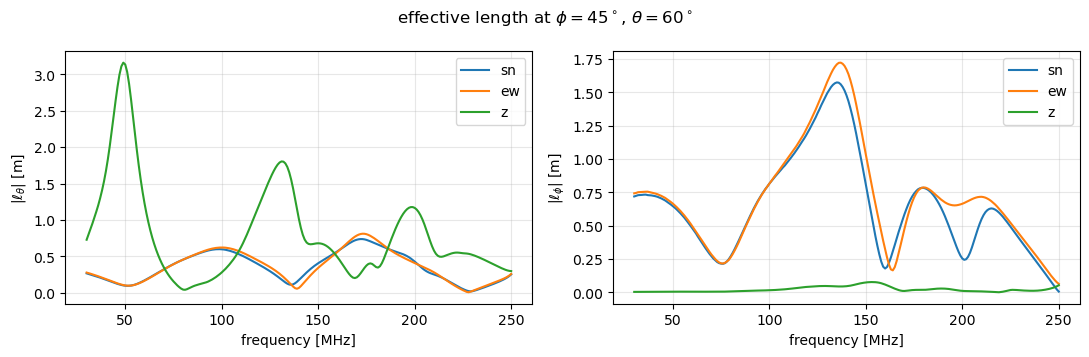

In [3]:
freq_mhz = t.frequency / 1e6

# Pick one arrival direction to hold fixed.  np.argmin(|axis - value|) is the
# idiom for "nearest tabulated point", used rather than interpolating because
# the grid is 1 degree and we only want a representative slice.
i_phi   = int(np.argmin(np.abs(t.phi - 45.0)))     # 45 deg azimuth
i_theta = int(np.argmin(np.abs(t.theta - 60.0)))   # 60 deg zenith: a typical
                                                   # inclined shower

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for name, arm in model.d_leff.items():
    # Index order is [frequency, azimuth, zenith], so this slices out a spectrum
    # at one direction.  np.abs() of the complex response is its magnitude in
    # metres; the phase is looked at separately in section 5.
    ax[0].plot(freq_mhz, np.abs(arm.leff_theta_reim[:, i_phi, i_theta]), label=name)
    ax[1].plot(freq_mhz, np.abs(arm.leff_phi_reim[:, i_phi, i_theta]),   label=name)

ax[0].set_ylabel(r'$|\ell_\theta|$ [m]')
ax[1].set_ylabel(r'$|\ell_\phi|$ [m]')
for a in ax:
    a.set_xlabel('frequency [MHz]')
    a.grid(alpha=.3)
    a.legend()
fig.suptitle(r'effective length at $\phi=45^\circ$, $\theta=60^\circ$')
fig.tight_layout()

Two things to read off this figure.

First, the resonance near 100–150 MHz: that is where the arms are electrically
a useful fraction of a wavelength.

Second, **the Z arm is not a scaled copy of the horizontal arms**. It has a
different shape entirely, and it carries almost all of its response in
$\ell_\theta$ while the horizontal arms carry most of theirs in $\ell_\phi$.
That asymmetry propagates all the way to the noise budget and to which arm sees
a given shower — notebook 06 section 4 is the consequence.

## 3. The directional map

Fixing the frequency instead and sweeping direction gives the beam pattern.
Figure 5 of [arXiv:2408.10926](https://arxiv.org/abs/2408.10926) shows the same
quantity.

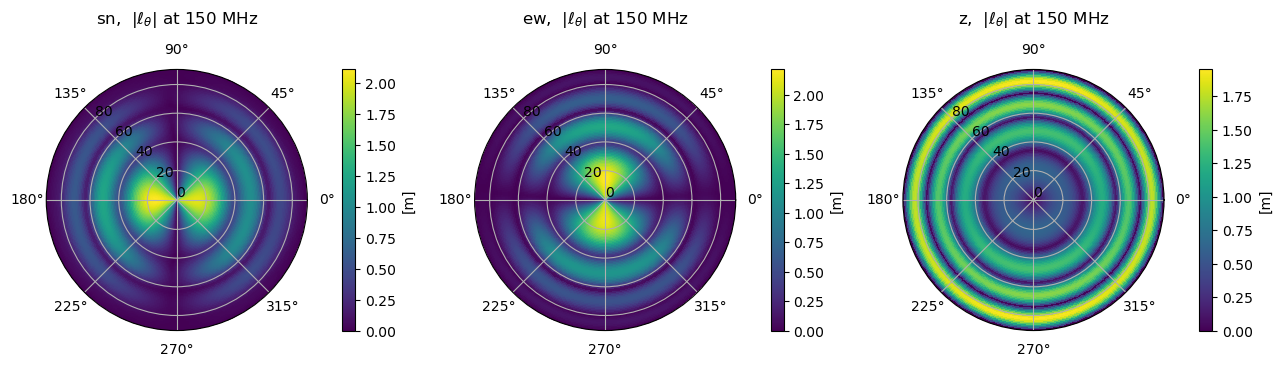

In [4]:
i_f = int(np.argmin(np.abs(freq_mhz - 150.0)))    # mid-band

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4),
                         subplot_kw=dict(projection='polar'))

# Polar axes want radians for the angular coordinate and take the radial
# coordinate as-is, so azimuth is converted and zenith is not.  indexing='ij'
# keeps the meshgrid in (phi, theta) order to match the table's axis order.
PHI, TH = np.meshgrid(np.radians(t.phi), t.theta, indexing='ij')

for ax, (name, arm) in zip(axes, model.d_leff.items()):
    amp = np.abs(arm.leff_theta_reim[i_f])        # (phi, theta) at this frequency
    pc = ax.pcolormesh(PHI, TH, amp, cmap='viridis', shading='auto')
    ax.set_title(r'%s,  $|\ell_\theta|$ at %.0f MHz' % (name, freq_mhz[i_f]), pad=14)
    ax.set_rlabel_position(135)                   # move the radial labels off the data
    fig.colorbar(pc, ax=ax, pad=.10, label='[m]')
fig.tight_layout()

The radial coordinate is zenith angle, so the **centre of each disc is
straight up** and the rim is the horizon.

The horizontal arms show the two-lobed pattern you would expect, aligned with
the arm. The Z arm is azimuthally symmetric and dark at the centre: a vertical
dipole cannot respond to a wave arriving from directly overhead. The next cell
puts numbers on both statements rather than leaving them to the eye.

In [5]:
# Verify the two claims above numerically rather than by looking at the figure.
print("at 150 MHz:")
for name, arm in model.d_leff.items():
    A = np.abs(arm.leff_theta_reim[i_f])          # (phi, theta)
    at_zenith  = A[:, 0].mean()                   # theta = 0 deg, straight up
    at_horizon = A[:, -1].mean()                  # theta = 90 deg
    # Coefficient of variation across azimuth: ~0 means azimuthally symmetric.
    spread = A[:, 60].std() / A[:, 60].mean()
    print("   %-4s |l_theta| at zenith %.4f m, at horizon %.4f m, "
          "azimuthal spread at 60 deg %.0f%%"
          % (name, at_zenith, at_horizon, 100 * spread))

at 150 MHz:
   sn   |l_theta| at zenith 1.2501 m, at horizon 0.0000 m, azimuthal spread at 60 deg 40%
   ew   |l_theta| at zenith 1.3113 m, at horizon 0.0000 m, azimuthal spread at 60 deg 41%
   z    |l_theta| at zenith 0.0037 m, at horizon 0.0000 m, azimuthal spread at 60 deg 2%


The Z arm reads 0.004 m at zenith against 1.25 m for the horizontal arms, and
its azimuthal spread is 2 % against 40 %. Both claims hold.

Every arm goes to exactly zero at the horizon, which is a property of the
tabulation rather than of the antenna: the model is not defined below the
horizontal.

## 4. Comparing the arms quantitatively

In [6]:
print("%-5s %10s %10s %10s" % ("arm", "peak", "median", "at MHz"))
for name, arm in model.d_leff.items():
    amp = np.abs(arm.leff_theta_reim)
    # unravel_index turns the flat argmax into (i_freq, i_phi, i_theta) so we can
    # report which frequency the peak sits at.
    i_pk = np.unravel_index(amp.argmax(), amp.shape)
    print("%-5s %9.2f m %8.3f m %9.0f"
          % (name, amp.max(), np.median(amp), freq_mhz[i_pk[0]]))

arm         peak     median     at MHz
sn         2.39 m    0.304 m       142


ew         2.54 m    0.300 m       142


z          3.22 m    0.589 m        49


The horizontal arms peak at 142 MHz and the Z arm at 49 MHz — a different
resonance, not a different scale. An analysis that assumes the three channels
share a band shape is assuming something false.

## 5. Phase matters too

The effective length is complex, so the antenna does not merely scale the field
— it disperses it. Unwrapping the phase along frequency gives a group delay;
ignoring it would smear the sub-nanosecond timing that GRAND's reconstruction
depends on.

group delay over 50-200 MHz: 2.83 ns


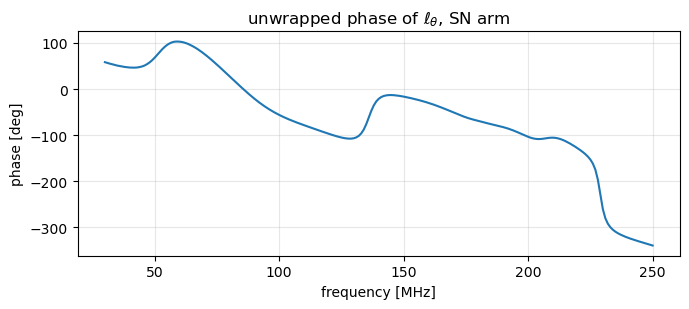

In [7]:
z = t.leff_theta_reim[:, i_phi, i_theta]

# np.angle gives the phase in (-pi, pi], which wraps.  np.unwrap removes the
# 2-pi jumps so that the slope below is meaningful.
phase = np.unwrap(np.angle(z))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(freq_mhz, np.degrees(phase))
ax.set_xlabel('frequency [MHz]')
ax.set_ylabel('phase [deg]')
ax.set_title(r'unwrapped phase of $\ell_\theta$, SN arm')
ax.grid(alpha=.3)
fig.tight_layout()

# A linear phase in frequency is a pure delay: phi = -2 pi nu tau, so the group
# delay is minus the slope over 2 pi.  Fit only over the part of the band where
# the response is large, since the phase is meaningless where the magnitude is
# near zero.
band = (freq_mhz > 50) & (freq_mhz < 200)
slope = np.polyfit(t.frequency[band], phase[band], 1)[0]   # rad per Hz
print("group delay over 50-200 MHz: %.2f ns" % (-slope / (2 * np.pi) * 1e9))

## 6. A note for contributors

`AntennaModel.plot_effective_length()` exists but its body is `pass` — it is a
stub. The plots above are what it was presumably meant to produce. If you fill
it in, the figures in this notebook are a reasonable specification.

## Where next

- [02 — Reading and writing GRAND data](02_data_model.ipynb)
- [04 — The RF chain](04_rf_chain.ipynb) — what happens to $V_{\rm oc}$ next
- [05 — Galactic noise](05_galactic_noise.ipynb) — why the Z arm matters